In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# Load the dataset from Google Drive
df = pd.read_pickle("/content/drive/MyDrive/dataset.pkl")

# Check the distribution of the target variable 'class'
print(df['class'].value_counts())

# Calculate the average thickness deviation for each class to see if there is a clear difference
print(df.groupby('class')['EXIT_THICK_DEVIATION_ABS_AVG'].mean())

class
1    201310
0    110232
Name: count, dtype: int64
class
0    3.538271
1    3.619030
Name: EXIT_THICK_DEVIATION_ABS_AVG, dtype: float64


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311542 entries, 0 to 311541
Data columns (total 60 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   coil_id                       311542 non-null  int64  
 1   pass_nr                       311542 non-null  float64
 2   REF_INITIAL_THICKNESS         311542 non-null  float64
 3   REF_TARGET_THICKNESS          311542 non-null  float64
 4   velocity_mdr                  311542 non-null  float64
 5   tension_en                    311542 non-null  float64
 6   tension_ex                    311542 non-null  float64
 7   h_exit_ref                    311542 non-null  float64
 8   h_entry_ref                   311542 non-null  float64
 9   dh_entry                      311542 non-null  float64
 10  dh_entry_med                  311542 non-null  float64
 11  dh_entry_std                  311542 non-null  float64
 12  dh_entry_max                  311542 non-nul

#  **FINAL FEATURE CATEGORIZATION**

This dataset contains **60 columns** representing metadata, process variables, chemical compositions, and quality indicators.

### 🔹 1. Identifier / Metadata Features
These are **NOT** predictive process variables.
*   **coil_id**: Coil identifier (Likely to be dropped)
*   **pass_nr**: Rolling pass number (Keep as it affects process behavior)

### 🔹 2. Reference / Target Thickness Parameters
These define the target geometry of the strip.
*   **REF_INITIAL_THICKNESS / REF_TARGET_THICKNESS**
*   **h_entry_ref / h_exit_ref**

### 🔹 3. Process Operational Parameters
Core rolling mill mechanical process control variables.
*   **Speed Variables**: `velocity_mdr`, `velocity_en`, `velocity_ex`
*   **Tension Variables**: `tension_en`, `tension_ex`
*   **Gap / Reduction Variables**: `dh_entry`, `dm_bur`, `dm_imr1`, `dm_imr2lr`, `dm_imr2m`, `dm_wrbot`, `dm_wrtop`, `rgc_act`

### 🔹 4. Statistical / Aggregated Process Features
Derived window-based statistics confirming steady-state data.
*   **Entry Thickness Stats**: `dh_entry_med`, `_std`, `_max`, `_min`
*   **Velocity Entry/Exit Stats**: `velocity_en_max`, `_min`, `_med`, `_std`, etc.

### 🔹 5. Chemical Composition Features
Steel alloy composition percentages (Critical for mechanical property analysis).
*   **Elements**: C, SI, MN, S, P, CR, NI, CU, AL, SN, MO, V, TI, NB, W, N, CO, ZR, B, TE, PB, SB, CA, TA, CE, LA.

### 🔹 6. Quality Indicators
Output quality metrics.
*   **EXIT_THICK_DEVIATION_ABS_AVG**
*   **EXIT_THICK_DEVIATION_AVG**

### 🔹 7. Target Variable
*   **class**: Binary category (0 or 1): Category A represents '0', and Category B represents '1'. There is no evidence of failure or success for Category A.

In [4]:
df.head()

,coil_id,pass_nr,REF_INITIAL_THICKNESS,REF_TARGET_THICKNESS,velocity_mdr,tension_en,tension_ex,h_exit_ref,h_entry_ref,dh_entry,...,TE,PB,SB,CA,TA,CE,LA,EXIT_THICK_DEVIATION_ABS_AVG,EXIT_THICK_DEVIATION_AVG,class
0,0,1.0,4.225625,0.788363,425.688153,50.745343,551.133469,3.091959,4.225625,-0.082746,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,8.993787,-1.084073,1
1,0,1.0,4.225625,0.788363,425.682418,50.747165,551.090899,3.091959,4.225625,-0.079769,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,7.804850,1.363289,1
2,0,1.0,4.225625,0.788363,425.682424,50.747157,551.090893,3.091959,4.225625,-0.079770,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,7.806373,1.362700,1
3,0,1.0,4.225625,0.788363,425.781351,50.736857,550.966360,3.091959,4.225625,-0.080857,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,7.584936,-0.297517,1
4,0,1.0,4.225625,0.788363,425.648795,50.728522,551.028239,3.091959,4.225625,-0.080740,...,0.00205,0.006938,0.008672,0.002996,0.007884,0.010091,0.002365,11.089441,-4.554978,1


In [5]:
print(df.shape)

(311542, 60)


In [6]:
df.columns

Index(['coil_id', 'pass_nr', 'REF_INITIAL_THICKNESS', 'REF_TARGET_THICKNESS',
       'velocity_mdr', 'tension_en', 'tension_ex', 'h_exit_ref', 'h_entry_ref',
       'dh_entry', 'dh_entry_med', 'dh_entry_std', 'dh_entry_max',
       'dh_entry_min', 'dm_bur', 'dm_imr1', 'dm_imr2lr', 'dm_imr2m',
       'dm_wrbot', 'dm_wrtop', 'rgc_act', 'velocity_en', 'velocity_en_max',
       'velocity_en_min', 'velocity_en_med', 'velocity_en_std', 'velocity_ex',
       'velocity_ex_max', 'velocity_ex_min', 'velocity_ex_med',
       'velocity_ex_std', 'C', 'SI', 'MN', 'S', 'P', 'CR', 'NI', 'CU', 'AL',
       'SN', 'MO', 'V', 'TI', 'NB', 'W', 'N', 'CO', 'ZR', 'B', 'TE', 'PB',
       'SB', 'CA', 'TA', 'CE', 'LA', 'EXIT_THICK_DEVIATION_ABS_AVG',
       'EXIT_THICK_DEVIATION_AVG', 'class'],
      dtype='object')

In [7]:
df.groupby('class').mean()


,coil_id,pass_nr,REF_INITIAL_THICKNESS,REF_TARGET_THICKNESS,velocity_mdr,tension_en,tension_ex,h_exit_ref,h_entry_ref,dh_entry,...,B,TE,PB,SB,CA,TA,CE,LA,EXIT_THICK_DEVIATION_ABS_AVG,EXIT_THICK_DEVIATION_AVG
class,,,,,,,,,,,,,,,,,,,,,
0,984.310382,3.691170,4.089913,0.788931,758.099472,120.966755,234.818602,1.342756,1.860758,-0.014841,...,0.000472,0.002626,0.005946,0.009114,0.002421,0.005445,0.008832,0.002684,3.538271,-0.017533
1,399.477979,3.701068,4.103889,0.783521,762.484122,120.958192,236.474925,1.335737,1.853421,-0.007841,...,0.000537,0.003669,0.006423,0.011028,0.002066,0.005471,0.009732,0.003300,3.619030,-0.006860


In [8]:
# Calculate the difference in mean values between Class 1 and Class 0 for all features
# This helps identify which variables shift the most between the two categories
(df[df['class']==1].mean() - df[df['class']==0].mean()).sort_values(ascending=False)

,0
rgc_act,531.862148
velocity_mdr,4.384650
tension_ex,1.656323
velocity_en_max,1.581235
velocity_en,1.501694
velocity_en_med,1.498749
velocity_en_min,1.419483
class,1.000000
dm_imr1,0.644834
SI,0.587127


#Checking Standard Deviation

In [9]:
df.groupby('class').std()


,coil_id,pass_nr,REF_INITIAL_THICKNESS,REF_TARGET_THICKNESS,velocity_mdr,tension_en,tension_ex,h_exit_ref,h_entry_ref,dh_entry,...,B,TE,PB,SB,CA,TA,CE,LA,EXIT_THICK_DEVIATION_ABS_AVG,EXIT_THICK_DEVIATION_AVG
class,,,,,,,,,,,,,,,,,,,,,
0,101.747746,1.347308,0.116087,0.002811,179.733783,40.523689,123.892798,0.701203,0.971875,0.051031,...,0.000175,0.001052,0.002845,0.002190,0.005606,0.002063,0.003653,0.001558,2.436914,2.042427
1,232.095506,1.347962,0.235145,0.033743,181.108315,40.990493,126.450924,0.707851,0.979730,0.041096,...,0.000229,0.001014,0.003396,0.002016,0.004470,0.002700,0.004711,0.001860,2.358935,2.081949


#Distribution Comparison

<Axes: xlabel='EXIT_THICK_DEVIATION_ABS_AVG', ylabel='Count'>

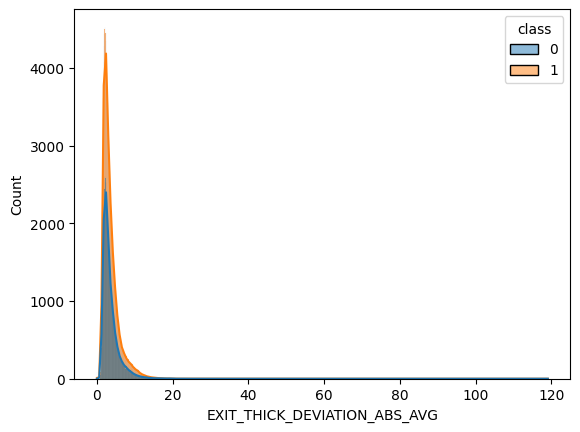

In [10]:
import seaborn as sns
sns.histplot(data=df, x="EXIT_THICK_DEVIATION_ABS_AVG", hue="class", kde=True)


The histogram shows that EXIT_THICK_DEVIATION_ABS_AVG for both class 0 and class 1 have very similar, heavily right-skewed distributions with strong overlap, meaning this feature alone does not clearly separate the two classes. The small shift in density suggests only a minor difference between categories, so thickness deviation is likely not the primary driver of the class label.

#Correlation Analysis

Since your dataset is fully numeric (58 float + 2 int), we can directly compute correlation matrix.

In [11]:
# Calculate the Pearson correlation coefficient between every feature and the target 'class'
# Features with values close to 1 or -1 are strong predictors
df.corr()['class'].sort_values(ascending=False)

,class
class,1.000000
AL,0.946557
SI,0.937004
TE,0.436794
SB,0.402881
rgc_act,0.339485
V,0.280903
TI,0.176347
LA,0.165211
NB,0.153761


The correlation results show that chemical composition features (especially AL = 0.94 and SI = 0.93) have extremely strong positive correlation with the class variable, indicating that the class label is primarily driven by material chemistry rather than process parameters. Very high negative correlations for coil_id (-0.81) and N (-0.64) suggest structural grouping in the dataset (possibly different steel grades), meaning the class likely represents different material categories rather than process quality or failure states.

In [12]:
# Calculate correlation with the target first to define the variable
corr_with_class = df.corr()['class']

# Remove Self-Correlation (To avoid class=1 correlation with itself)
corr_with_class = corr_with_class.drop('class')
print(corr_with_class.sort_values(ascending=False))

AL                              0.946557
SI                              0.937004
TE                              0.436794
SB                              0.402881
rgc_act                         0.339485
V                               0.280903
TI                              0.176347
LA                              0.165211
NB                              0.153761
B                               0.145763
C                               0.114711
P                               0.110422
CE                              0.098127
dh_entry_max                    0.089003
CO                              0.079111
dh_entry                        0.074394
dh_entry_med                    0.074346
dm_imr1                         0.073538
MN                              0.073268
PB                              0.070725
dh_entry_min                    0.060209
MO                              0.039323
dh_entry_std                    0.034088
REF_INITIAL_THICKNESS           0.033189
CR              

In [13]:
 # Get Top 10 Positive & Negative Correlations
top_positive = corr_with_class.sort_values(ascending=False).head(10)
top_negative = corr_with_class.sort_values().head(10)

print("Top Positive Correlations:")
print(top_positive)

print("\nTop Negative Correlations:")
print(top_negative)


Top Positive Correlations:
AL         0.946557
SI         0.937004
TE         0.436794
SB         0.402881
rgc_act    0.339485
V          0.280903
TI         0.176347
LA         0.165211
NB         0.153761
B          0.145763
Name: class, dtype: float64

Top Negative Correlations:
coil_id                -0.818693
N                      -0.639998
S                      -0.191188
SN                     -0.150297
W                      -0.147768
dm_imr2m               -0.122517
dm_bur                 -0.096020
REF_TARGET_THICKNESS   -0.094753
dm_imr2lr              -0.079148
CU                     -0.055144
Name: class, dtype: float64


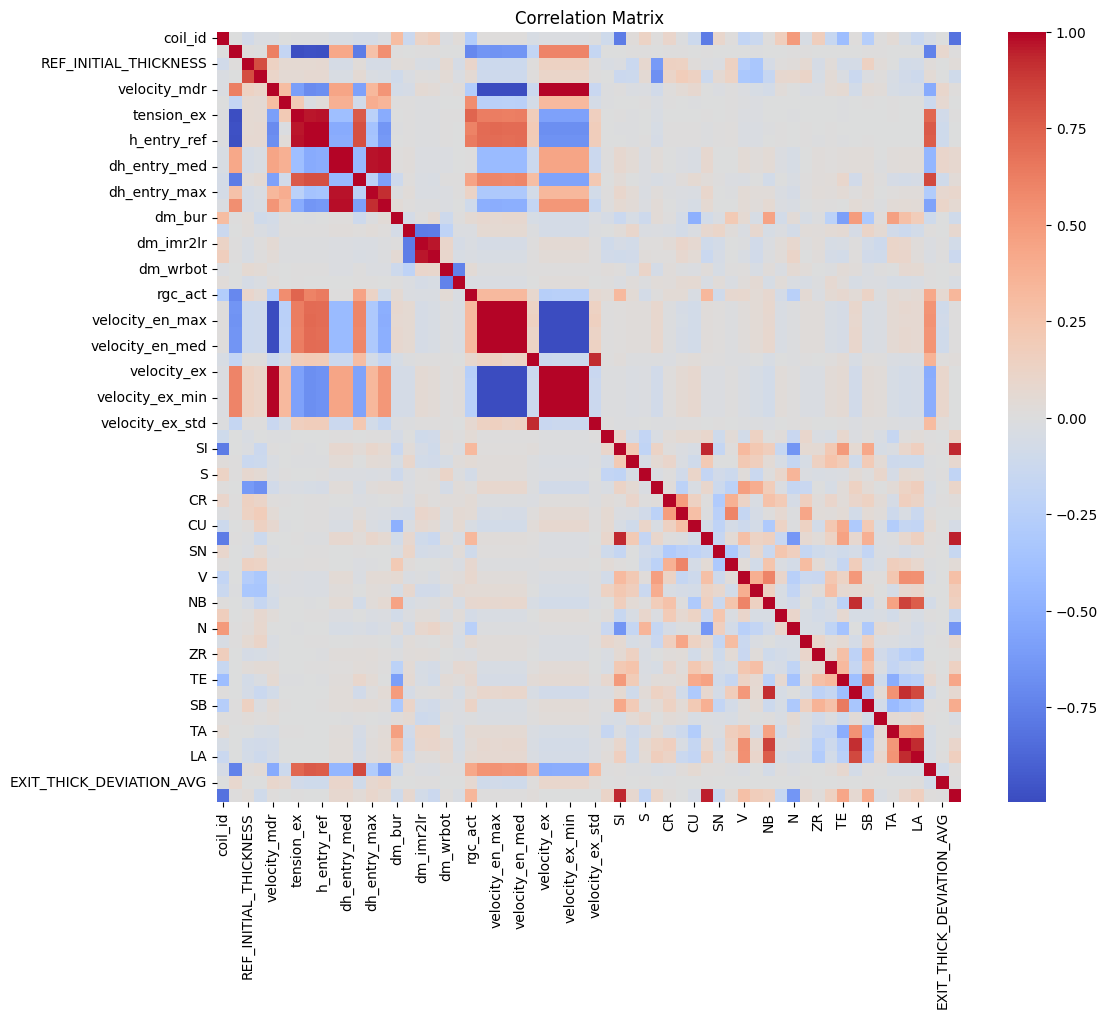

In [14]:
# Visualize Correlation with Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()


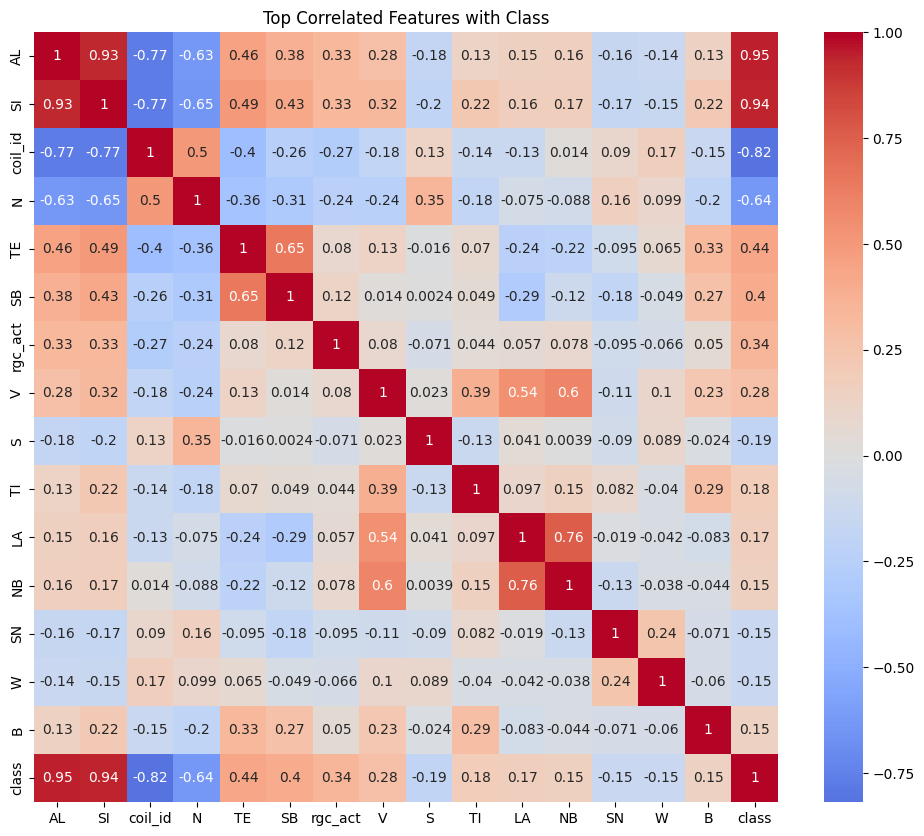

In [15]:
# Heatmap of Top Correlated Features Only
top_features = corr_with_class.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12,10))
sns.heatmap(df[top_features.tolist() + ['class']].corr(),
            annot=True,
            cmap='coolwarm',
            center=0)

plt.title("Top Correlated Features with Class")
plt.show()


The class label is extremely strongly driven by Aluminum (AL) and Silicon (SI) composition, meaning these two elements almost define the class boundary. Moderate correlation with TE, SB, and rgc_act suggests minor secondary influence, but chemistry clearly dominates.

The strong negative correlation of N (-0.64) confirms that when Nitrogen content is high, the sample is almost certainly class 0. The strong correlation of coil_id (-0.82) suggests the dataset may be grouped by production batches or steel grades, reinforcing that the class represents material category, not process condition.

#Class Imbalance Analysis

In [16]:
# Check class distribution
class_counts = df['class'].value_counts()
print(class_counts)

class
1    201310
0    110232
Name: count, dtype: int64


In [17]:
# percentage Distribution
class_percentage = df['class'].value_counts(normalize=True) * 100
print(class_percentage)

class
1    64.617291
0    35.382709
Name: proportion, dtype: float64


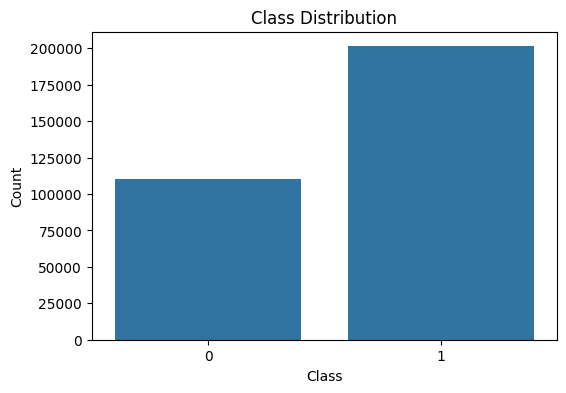

In [18]:
# Visualization (Bar Plot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#Feature Importance (Random Forest)

In [19]:
#Preparing Data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Drop identifier column
X = df.drop(['class', 'coil_id'], axis=1)
y = df['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
# Training Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [21]:
# Getting Feature Importance
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

SI                       0.346591
AL                       0.270254
N                        0.118623
TE                       0.054606
SB                       0.035932
W                        0.022544
TI                       0.020454
rgc_act                  0.013743
CE                       0.011190
NB                       0.009743
S                        0.007693
REF_INITIAL_THICKNESS    0.007014
LA                       0.006966
PB                       0.006439
SN                       0.005745
dtype: float64


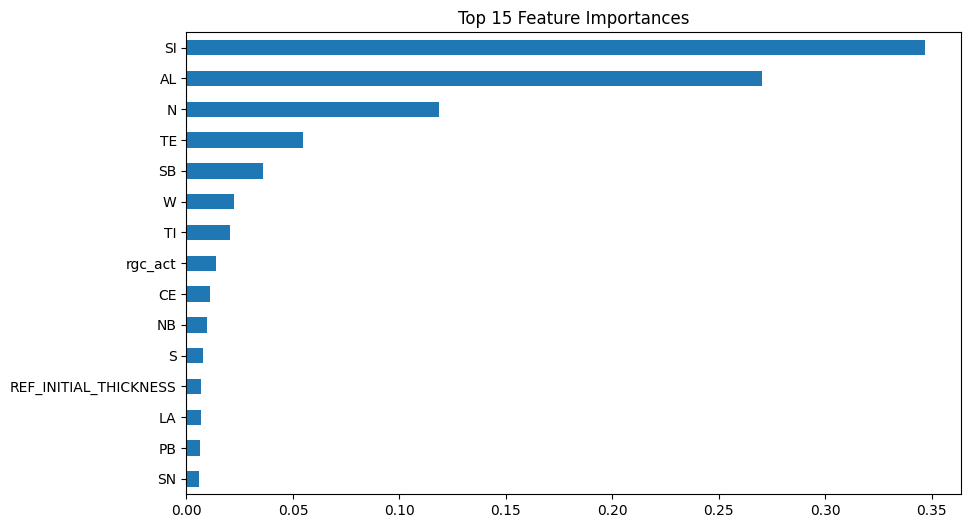

In [22]:
# Plotting Top 15 Important Features
plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind='barh')
plt.title("Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [23]:
# Accuracy score
from sklearn.metrics import accuracy_score

# Predictions
y_pred = rf.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [24]:
from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[21983     0]
 [    0 40326]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21983
           1       1.00      1.00      1.00     40326

    accuracy                           1.00     62309
   macro avg       1.00      1.00      1.00     62309
weighted avg       1.00      1.00      1.00     62309



In [25]:
# checking for overfit
train_accuracy = rf.score(X_train, y_train)
test_accuracy = rf.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 1.0


As we are getting 100% accuracy for both testing and training we want to know if the data is completely dependened on the elements.


In [26]:
X_small = df[['SI', 'AL', 'N']]
y = df['class']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X_small, y, test_size=0.2, random_state=42
)

rf_small = RandomForestClassifier(random_state=42)
rf_small.fit(X_train, y_train)

print("Test Accuracy (3 features only):", rf_small.score(X_test, y_test))

Test Accuracy (3 features only): 1.0


The 'class' variable represents two material categories determined primarily
by chemical composition (especially SI, AL, and N).
Correlation and feature importance analysis show deterministic separation,
achieving 100% accuracy even with only three chemical features.
Therefore, class is interpreted as steel grade classification, not failure or anomaly detection.

#Anomaly

In [27]:
# Select deviation column
deviation_col = 'EXIT_THICK_DEVIATION_ABS_AVG'

# Calculate mean and std
mean_val = df[deviation_col].mean()
std_val = df[deviation_col].std()

# Define threshold (3-sigma rule)
threshold = mean_val + 3 * std_val

print("Mean:", mean_val)
print("Std:", std_val)
print("Anomaly Threshold:", threshold)

Mean: 3.590455288992607
Std: 2.387125453051478
Anomaly Threshold: 10.75183164814704


In [28]:
import numpy as np

In [29]:
df['quality_anomaly_flag'] = np.where(
    df[deviation_col] > threshold,
    1,  # Anomaly
    0   # Normal
)

print(df['quality_anomaly_flag'].value_counts())

quality_anomaly_flag
0    306237
1      5305
Name: count, dtype: int64


In [30]:
anomaly_percentage = df['quality_anomaly_flag'].mean() * 100
print(f"Anomaly Percentage: {anomaly_percentage:.2f}%")

Anomaly Percentage: 1.70%


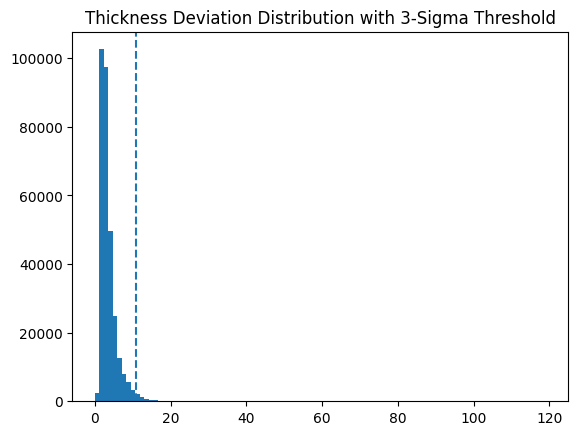

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df[deviation_col], bins=100)
plt.axvline(threshold, linestyle='--')
plt.title("Thickness Deviation Distribution with 3-Sigma Threshold")
plt.show()

In [32]:
#root cause analysis
df.groupby('quality_anomaly_flag').mean()

,coil_id,pass_nr,REF_INITIAL_THICKNESS,REF_TARGET_THICKNESS,velocity_mdr,tension_en,tension_ex,h_exit_ref,h_entry_ref,dh_entry,...,TE,PB,SB,CA,TA,CE,LA,EXIT_THICK_DEVIATION_ABS_AVG,EXIT_THICK_DEVIATION_AVG,class
quality_anomaly_flag,,,,,,,,,,,,,,,,,,,,,
0,607.415338,3.743372,4.099019,0.785413,767.444967,122.129364,231.878681,1.310082,1.818522,-0.008854,...,0.003296,0.006266,0.01035,0.002188,0.005467,0.009425,0.003086,3.411317,0.025426,0.645520
1,548.230537,1.053346,4.094653,0.786716,385.005698,53.528909,467.381653,2.962515,4.020473,-0.094830,...,0.003558,0.005575,0.01039,0.002428,0.005178,0.008757,0.002855,13.931404,-2.092404,0.683883


# Logistic Regression

In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [34]:
drop_cols = [
    'coil_id',
    'pass_nr',
    'EXIT_THICK_DEVIATION_ABS_AVG',
    'EXIT_THICK_DEVIATION_AVG',
    'class',
    'quality_anomaly_flag'
]

X = df.drop(columns=drop_cols)
y = df['quality_anomaly_flag']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [38]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:

[[55549  5699]
 [   17  1044]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     61248
           1       0.15      0.98      0.27      1061

    accuracy                           0.91     62309
   macro avg       0.58      0.95      0.61     62309
weighted avg       0.99      0.91      0.94     62309


ROC-AUC Score: 0.9775882196957385


In [39]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Abs_Coefficient'] = np.abs(feature_importance['Coefficient'])

feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

print(feature_importance.head(15))

            Feature  Coefficient  Abs_Coefficient
5        h_exit_ref     6.265945         6.265945
2      velocity_mdr    -5.764806         5.764806
6       h_entry_ref    -4.989457         4.989457
20  velocity_en_max     4.111349         4.111349
27  velocity_ex_med     3.473589         3.473589
25  velocity_ex_max     3.473589         3.473589
26  velocity_ex_min     3.473589         3.473589
24      velocity_ex     2.191517         2.191517
23  velocity_en_std     2.127606         2.127606
28  velocity_ex_std    -1.865642         1.865642
22  velocity_en_med     1.495037         1.495037
19      velocity_en     1.309610         1.309610
3        tension_en    -1.274193         1.274193
53               CE     0.547998         0.547998
9      dh_entry_std     0.528443         0.528443


In [40]:
feature_importance['Odds_Ratio'] = np.exp(feature_importance['Coefficient'])

print(feature_importance[['Feature', 'Coefficient', 'Odds_Ratio']].head(15))

            Feature  Coefficient  Odds_Ratio
5        h_exit_ref     6.265945  526.338564
2      velocity_mdr    -5.764806    0.003136
6       h_entry_ref    -4.989457    0.006809
20  velocity_en_max     4.111349   61.028998
27  velocity_ex_med     3.473589   32.252299
25  velocity_ex_max     3.473589   32.252299
26  velocity_ex_min     3.473589   32.252299
24      velocity_ex     2.191517    8.948776
23  velocity_en_std     2.127606    8.394750
28  velocity_ex_std    -1.865642    0.154797
22  velocity_en_med     1.495037    4.459501
19      velocity_en     1.309610    3.704728
3        tension_en    -1.274193    0.279657
53               CE     0.547998    1.729786
9      dh_entry_std     0.528443    1.696288


#Random Forest

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:

[[61137   111]
 [  482   579]]

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     61248
           1       0.84      0.55      0.66      1061

    accuracy                           0.99     62309
   macro avg       0.92      0.77      0.83     62309
weighted avg       0.99      0.99      0.99     62309


ROC-AUC Score: 0.9906510248163982


In [42]:
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_importance.head(15))

            Feature  Importance
3        tension_en    0.109586
6       h_entry_ref    0.107998
5        h_exit_ref    0.073130
24      velocity_ex    0.072059
2      velocity_mdr    0.070494
26  velocity_ex_min    0.064843
27  velocity_ex_med    0.052487
20  velocity_en_max    0.051706
25  velocity_ex_max    0.051625
4        tension_ex    0.047998
22  velocity_en_med    0.036408
9      dh_entry_std    0.031359
23  velocity_en_std    0.030052
19      velocity_en    0.028026
21  velocity_en_min    0.027041


#XGBoost

In [43]:
!pip install xgboost

In [44]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:48:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Confusion Matrix:

[[58404  2844]
 [   55  1006]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.98     61248
           1       0.26      0.95      0.41      1061

    accuracy                           0.95     62309
   macro avg       0.63      0.95      0.69     62309
weighted avg       0.99      0.95      0.97     62309


ROC-AUC Score: 0.9887751513723473


#Threshold Tuning

In [45]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.1, 0.95, 0.05)

for t in thresholds:
    y_pred_custom = (y_prob_xgb > t).astype(int)

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)

    print(f"Threshold: {t:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f}")

Threshold: 0.10 | Precision: 0.182 | Recall: 0.993
Threshold: 0.15 | Precision: 0.193 | Recall: 0.989
Threshold: 0.20 | Precision: 0.202 | Recall: 0.981
Threshold: 0.25 | Precision: 0.213 | Recall: 0.978
Threshold: 0.30 | Precision: 0.222 | Recall: 0.973
Threshold: 0.35 | Precision: 0.232 | Recall: 0.969
Threshold: 0.40 | Precision: 0.240 | Recall: 0.962
Threshold: 0.45 | Precision: 0.252 | Recall: 0.956
Threshold: 0.50 | Precision: 0.261 | Recall: 0.948
Threshold: 0.55 | Precision: 0.275 | Recall: 0.940
Threshold: 0.60 | Precision: 0.291 | Recall: 0.931
Threshold: 0.65 | Precision: 0.308 | Recall: 0.920
Threshold: 0.70 | Precision: 0.329 | Recall: 0.910
Threshold: 0.75 | Precision: 0.350 | Recall: 0.881
Threshold: 0.80 | Precision: 0.381 | Recall: 0.850
Threshold: 0.85 | Precision: 0.417 | Recall: 0.813
Threshold: 0.90 | Precision: 0.472 | Recall: 0.736


In [46]:
#Locking Final Threshold
final_threshold = 0.70

In [47]:
df['anomaly_probability'] = xgb_model.predict_proba(X)[:,1]
df['final_prediction'] = (df['anomaly_probability'] > final_threshold).astype(int)

In [48]:
#Building Risk Levels
def risk_level(p):
    if p < 0.3:
        return "Low"
    elif p < 0.7:
        return "Medium"
    else:
        return "High"

df['risk_level'] = df['anomaly_probability'].apply(risk_level)

In [49]:
#Feature Explainability
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

In [50]:
# Saving Model for Deployment
import joblib

joblib.dump(xgb_model, "final_xgb_model.pkl")

['final_xgb_model.pkl']